In [25]:
%pip install matplotlib pandas seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# estetical configurations
sns.set_theme()

# Predictive Analysis of Diabetes Risk
## Python Replication of the R Project

**Objective:** Quantify diabetes probability, focusing on the impact of Lifestyle and Genetics.
*Data Source: Diabetes and Lifestyle Dataset by Alam Shihab (Kaggle)*

In [27]:
#dataframe
df = pd.read_csv("files_to_analyse/Diabetes_and_LifeStyle_Dataset.csv")

## Data Cleaning and Preprocessing
Checking for missing values and transforming categorical variables into binary/numeric formats.

In [28]:
# Check for missing values (NA)
print("Missing values per column:")
print(df.isnull().sum())

# Filter out 'Other' gender
df = df[df['gender'] != 'Other']

# Transform 'smoking_status' to binary (1 = 'Never', 0 = Otherwise)
df['smoking_status'] = (df['smoking_status'] == 'Never').astype(int)

# Transform 'gender' to binary (1 = 'Male', 0 = 'Female')
df['gender'] = (df['gender'] == 'Male').astype(int)

# Ensure target variable is numeric
df['diagnosed_diabetes'] = df['diagnosed_diabetes'].astype(int)

# --- VERIFICATION ---
# Print the transformed columns to check logic
print("\nSample of transformed data:")
print(df[['gender', 'smoking_status', 'diagnosed_diabetes']].head(10))

print(f"\nRemaining rows after cleaning: {df.shape[0]}")

Missing values per column:
Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasti

## Descriptive Statistics & Visualization
Analysis of the target variable distribution, boxplots for key features, and correlation matrix.

In [29]:
# Check dataset structure (types and non-null counts)
print("--- Dataset Info ---")
df.info()

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicates}")

# Statistical summary of numerical variables
print("\n--- Statistical Summary ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.DataFrame'>
Index: 95333 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 95333 non-null  int64  
 1   gender                              95333 non-null  int64  
 2   ethnicity                           95333 non-null  str    
 3   education_level                     95333 non-null  str    
 4   income_level                        95333 non-null  str    
 5   employment_status                   95333 non-null  str    
 6   smoking_status                      95333 non-null  int64  
 7   alcohol_consumption_per_week        95333 non-null  int64  
 8   physical_activity_minutes_per_week  95333 non-null  int64  
 9   diet_score                          95333 non-null  float64
 10  sleep_hours_per_day                 95333 non-null  float64
 11  screen_time_hours_per_day           

Percentage of Diabetic individuals: 59.95%
Percentage of Healthy individuals: 40.05%


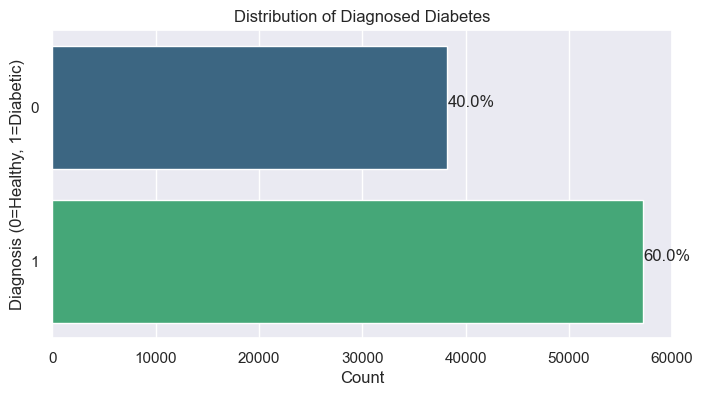

In [30]:
# Target Variable Distribution
total_obs = len(df)
diabetic_count = df['diagnosed_diabetes'].sum()
perc_diabetes = round((diabetic_count / total_obs) * 100, 2)
perc_healthy = 100 - perc_diabetes

print(f"Percentage of Diabetic individuals: {perc_diabetes}%")
print(f"Percentage of Healthy individuals: {perc_healthy}%")

# Visualization (Horizontal Bar Plot)
plt.figure(figsize=(8, 4))
# sns.countplot automatically counts the occurrences
ax = sns.countplot(y='diagnosed_diabetes', data=df,hue='diagnosed_diabetes', palette='viridis', legend=False)

plt.title('Distribution of Diagnosed Diabetes')
plt.xlabel('Count')
plt.ylabel('Diagnosis (0=Healthy, 1=Diabetic)')

# Add percentage labels on bars (Advanced touch for portfolio)
total = len(df['diagnosed_diabetes'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_width()/total)
    x = p.get_width() + 100
    y = p.get_y() + p.get_height()/2
    ax.annotate(percentage, (x, y))

plt.show()

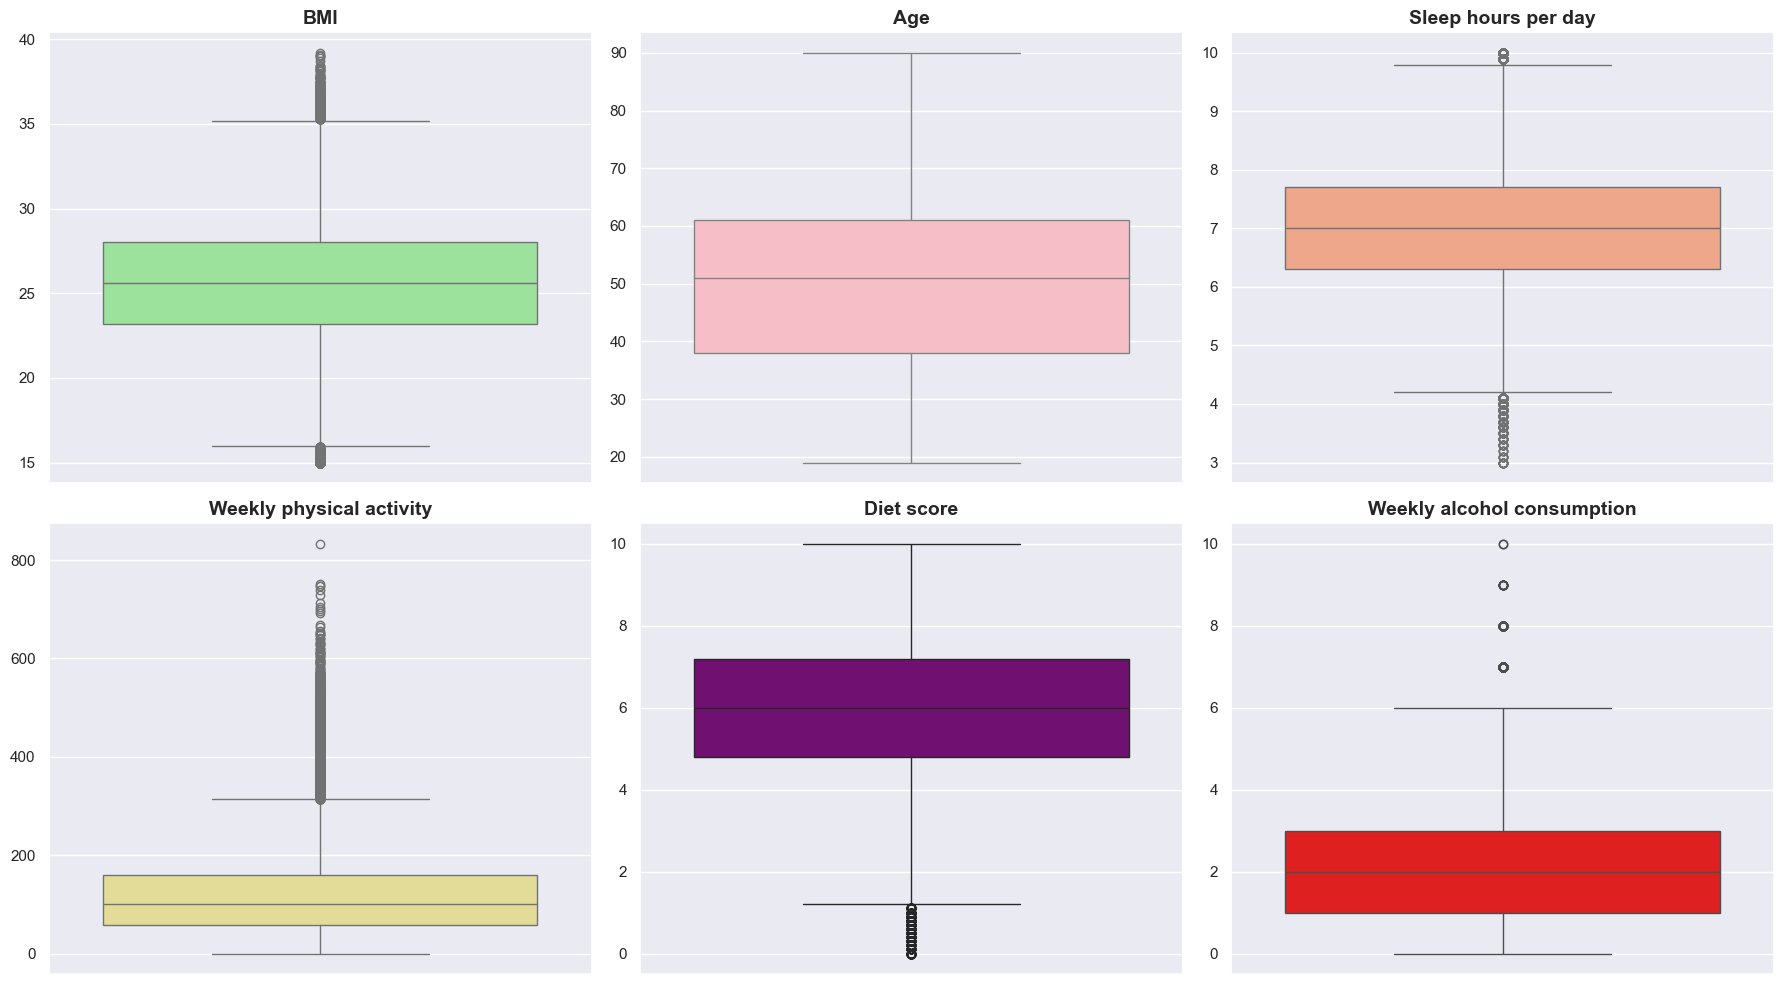

In [31]:
# Boxplots of Main Variables (Grid Layout)

# Set up the matplotlib figure: 2 rows, 3 columns, and a large figure size
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Flatten the 2x3 grid into a simple 1D array of 6 elements for the loop
axes = axes.flatten()

# Define a list of tuples containing: (column_name, title, color)
plots_info = [
    ('bmi', 'BMI', 'lightgreen'),
    ('Age', 'Age', 'lightpink'),
    ('sleep_hours_per_day', 'Sleep hours per day', 'lightsalmon'),
    ('physical_activity_minutes_per_week', 'Weekly physical activity', 'khaki'), # Note: 'khaki' is Python's closest to 'lightgoldenrod'
    ('diet_score', 'Diet score', 'purple'),
    ('alcohol_consumption_per_week', 'Weekly alcohol consumption', 'red')
]

# Loop through the list and create a boxplot for each variable
for i, (col, title, color) in enumerate(plots_info):
    # Draw the boxplot
    sns.boxplot(y=df[col], ax=axes[i], color=color)

    # Set the title and clean up the axis labels
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('') # We remove the default y-label to make it cleaner

# Adjust layout to prevent overlap between titles and graphs
plt.tight_layout()
plt.show()

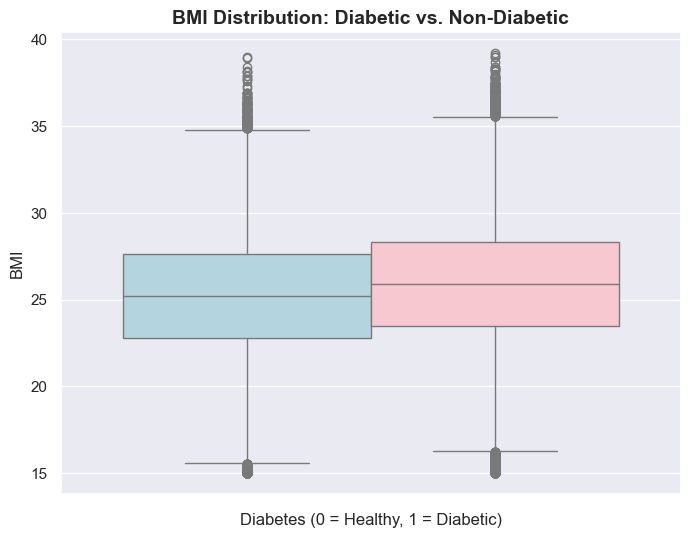

--------------------------------------------------


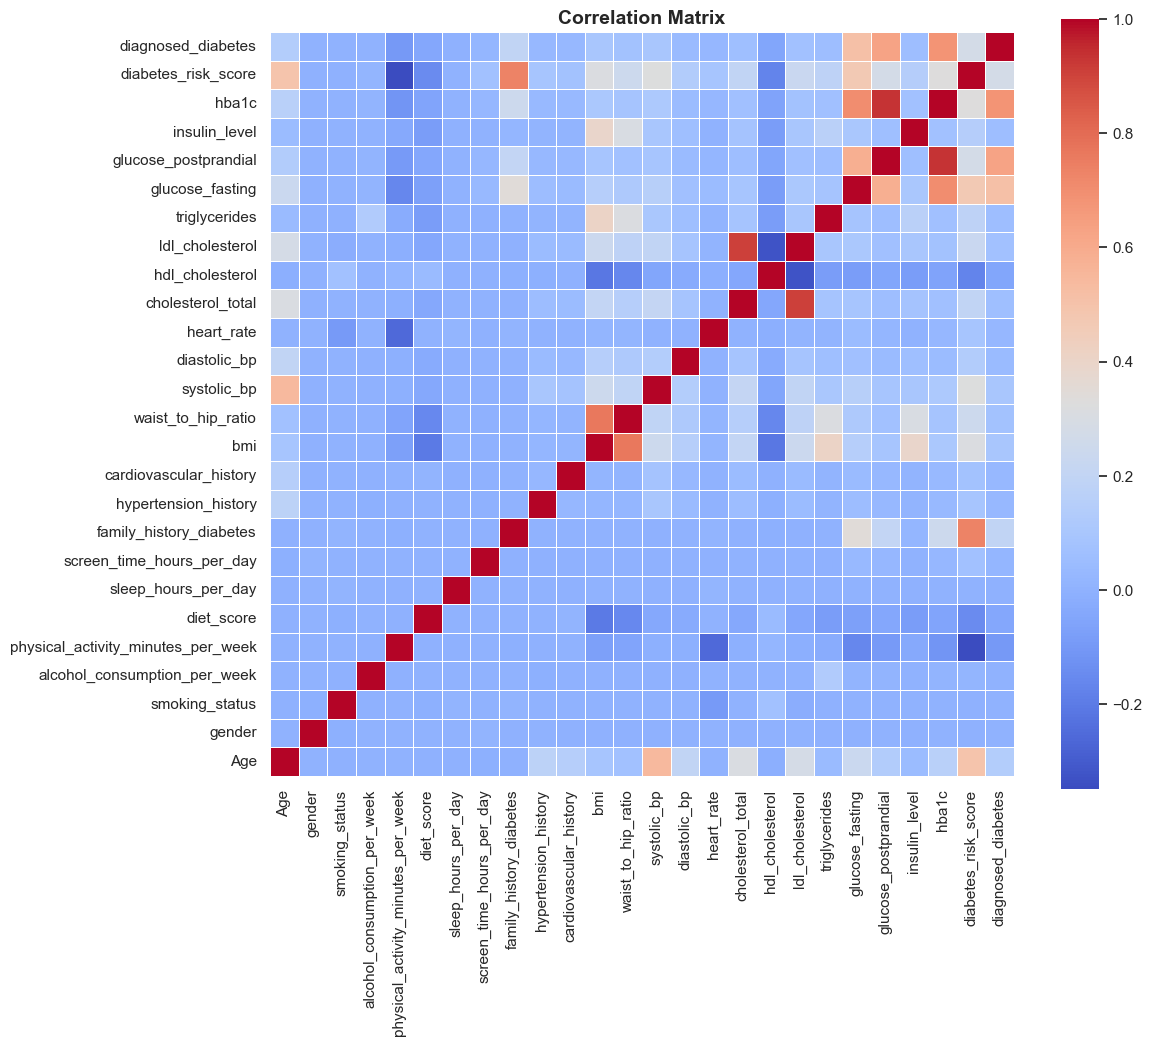

In [32]:
# Boxplot: BMI vs Diagnosed Diabetes
# Equivalent to ggplot(df, aes(x=as.factor(diagnosed_diabetes), y=bmi)) + geom_boxplot()
plt.figure(figsize=(8, 6))
sns.boxplot(hue='diagnosed_diabetes', y='bmi', data=df, palette=['lightblue', 'pink'], legend=False)

plt.title('BMI Distribution: Diabetic vs. Non-Diabetic', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes (0 = Healthy, 1 = Diabetic)')
plt.ylabel('BMI')
plt.show()  # This prints the first plot before moving to the next one

print("-" * 50) # Just a visual separator in the output

# Correlation Matrix
# Equivalent to: subdf=df[ , c(1,8,...)] and ggcorrplot(cor(subdf))

# Instead of hardcoding column indices, we dynamically select all numeric columns
subdf = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = subdf.corr()

# Create the plot with a specific size
plt.figure(figsize=(12, 10))

# We assign the heatmap to the variable 'ax'
# Adding square=True makes it look exactly like R's ggcorrplot
ax = sns.heatmap(corr_matrix,
                 cmap='coolwarm',
                 annot=False,
                 linewidths=0.5,
                 square=True)

# In order to have the main diagonal starting from bottom left
ax.invert_yaxis()

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

## Logistic Regression (Full Model)
Fitting the logistic regression model to evaluate the impact of each predictor.

In [33]:
%pip install statsmodels
import statsmodels.formula.api as smf

# Define the formula and fit the model
formula = (
    "diagnosed_diabetes ~ Age + gender + bmi + "
    "physical_activity_minutes_per_week + sleep_hours_per_day + "
    "smoking_status + diet_score + hypertension_history + "
    "cardiovascular_history + alcohol_consumption_per_week + "
    "family_history_diabetes"
)

logistic_model = smf.logit(formula=formula, data=df).fit()

# Print the full statistical summary
print(logistic_model.summary())


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Optimization terminated successfully.
         Current function value: 0.633263
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:     diagnosed_diabetes   No. Observations:                95333
Model:                          Logit   Df Residuals:                    95321
Method:                           MLE   Df Model:                           11
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.05932
Time:                        17:01:09   Log-Likelihood:                -60371.
converged:                       True   LL-Null:                       -64178.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Model Evaluation: Goodness of Fit
Calculating McFadden's Pseudo R-squared and performing the Likelihood Ratio Test (LRT).

In [34]:
# MCFADDEN'S R^2
mf_r2 = logistic_model.prsquared
print(f"McFadden's R^2: {mf_r2:.4f}")

# LIKELIHOOD RATIO TEST (LRT)
LR = logistic_model.llr
k = logistic_model.df_model  # Degrees of freedom
p_value_LR = logistic_model.llr_pvalue

print("\n--- Likelihood Ratio Test (LRT) ---")
print(f"LR Statistic: {LR:.2f}")
print(f"Degrees of freedom (k): {k}")
print(f"P-value of LR Test: {p_value_LR}")

McFadden's R^2: 0.0593

--- Likelihood Ratio Test (LRT) ---
LR Statistic: 7614.17
Degrees of freedom (k): 11.0
P-value of LR Test: 0.0


### Multicollinearity Check
Calculating the Variance Inflation Factor (VIF) to ensure predictors are not highly correlated.

In [35]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# VARIANCE INFLATION FACTOR (VIF)
# Extract the design matrix (exog) from the model
exog = logistic_model.model.exog
exog_names = logistic_model.model.exog_names

# Create a DataFrame to store the VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = exog_names
vif_data["VIF_Factor"] = [variance_inflation_factor(exog, i) for i in range(exog.shape[1])]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data)

--- Variance Inflation Factor (VIF) ---
                              Variable  VIF_Factor
0                            Intercept  132.067459
1                                  Age    1.064477
2                               gender    1.000110
3                                  bmi    1.057617
4   physical_activity_minutes_per_week    1.005621
5                  sleep_hours_per_day    1.000132
6                       smoking_status    1.000219
7                           diet_score    1.043135
8                 hypertension_history    1.032797
9               cardiovascular_history    1.022492
10        alcohol_consumption_per_week    1.000152
11             family_history_diabetes    1.000154


In [36]:
## Model Evaluation & Confusion Matrix
# Evaluating the predictive power of the model using Accuracy, Sensitivity, and Specificity.
%pip install scikit-learn
from sklearn.metrics import confusion_matrix

# 1. Get predicted probabilities ON TRAINING DATA
# Equivalent to logistic_model$fitted.values
phat = logistic_model.predict(df)

# 2. Classify with a 0.5 threshold
# Equivalent to yhat <- as.numeric(phat > 0.5)
yhat = (phat > 0.5).astype(int)

# True labels
# Equivalent to y_true <- as.numeric(as.character(df$diagnosed_diabetes))
y_true = df['diagnosed_diabetes']

# --- CONFUSION MATRIX ---
# sklearn automatically calculates the matrix.
# .ravel() unpacks the 2x2 matrix into 4 distinct variables:
# tn (True Negative)  = c0 (Healthy predicted as Healthy)
# fp (False Positive) = w0 (Healthy predicted as Diabetic)
# fn (False Negative) = w1 (Diabetic predicted as Healthy)
# tp (True Positive)  = c1 (Diabetic predicted as Diabetic)
tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()

# Create a formatted table (DataFrame) similar to the R output
tab_predictions = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    columns=["Predicted Diabetic", "Predicted Healthy"],
    index=["Real Diabetic", "Real Healthy"]
)

print("--- Confusion Matrix ---")
print(tab_predictions)

# --- METRICS ---
# ACCURACY: total cases correctly identified divided by total cases
accuracy = (tn + tp) / len(y_true)
print(f"\nAccuracy: {accuracy:.4f}")

# SENSITIVITY: correct positive predictions divided by total positive cases
# Also known as Recall or True Positive Rate
sensitivity = tp / (tp + fn)
print(f"Sensitivity: {sensitivity:.4f}")

# SPECIFICITY: correct negative forecasts divided by total negative cases
# Also known as True Negative Rate
specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.4f}")

Note: you may need to restart the kernel to use updated packages.
--- Confusion Matrix ---
               Predicted Diabetic  Predicted Healthy
Real Diabetic               47001              10155
Real Healthy                24934              13243

Accuracy: 0.6319
Sensitivity: 0.8223
Specificity: 0.3469



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


AUC (Area Under the Curve): 0.6599


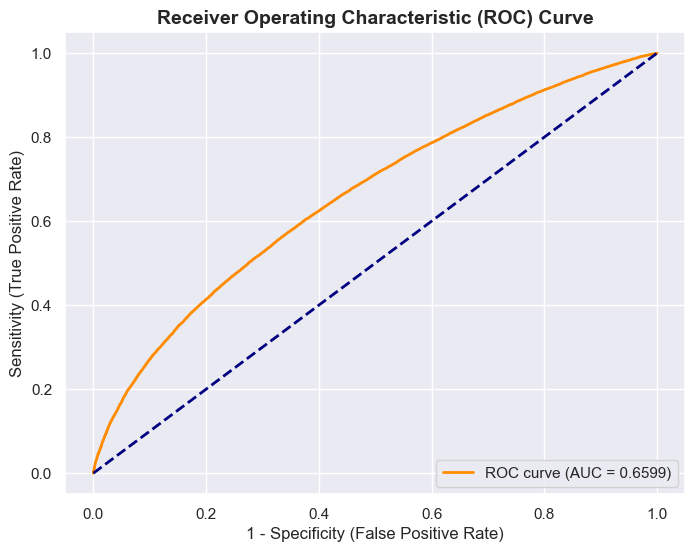

In [37]:
## ROC Curve and AUC
# Visualizing the Trade-off between Sensitivity and Specificity and calculating the Area Under the Curve.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculate the ROC curve points
# We directly use 'y_true' and 'phat' which were already computed in the previous cell.
fpr, tpr, thresholds = roc_curve(y_true, phat)

# 2. Calculate AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_true, phat)
print(f"AUC (Area Under the Curve): {roc_auc:.4f}")

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (random guess)

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.legend(loc="lower right")

plt.show()

## Model potimization
 Removing non-significant variables (Backward Elimination) and evaluating the new ROC curve.

--- Starting Backward Elimination ---
Dropped: alcohol_consumption_per_week        (p-value: 0.7687)
Dropped: smoking_status                      (p-value: 0.6818)
Dropped: sleep_hours_per_day                 (p-value: 0.6174)
Dropped: hypertension_history                (p-value: 0.4734)
Dropped: gender                              (p-value: 0.3651)

--- Final Optimized Model ---
Formula: diagnosed_diabetes ~ Age + bmi + physical_activity_minutes_per_week + diet_score + cardiovascular_history + family_history_diabetes
                           Logit Regression Results                           
Dep. Variable:     diagnosed_diabetes   No. Observations:                95333
Model:                          Logit   Df Residuals:                    95326
Method:                           MLE   Df Model:                            6
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.05931
Time:                        17:01:14   Log-Likelihood:                -60372.
c

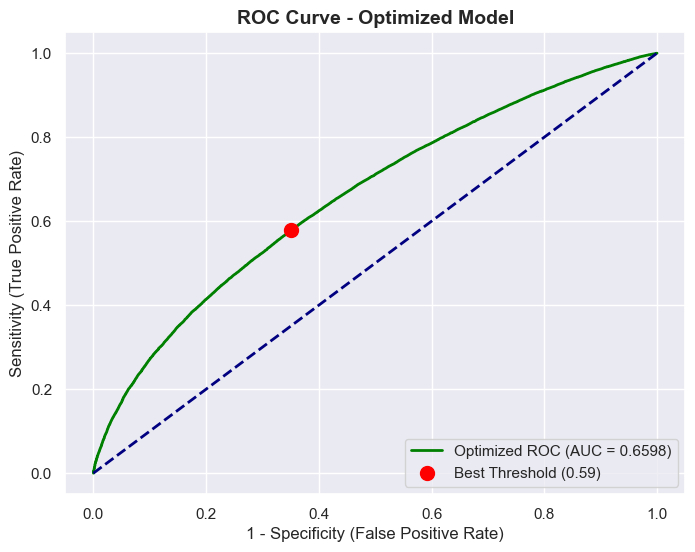

In [38]:
import numpy as np

# Define a custom function for Backward Elimination based on p-values
def backward_elimination(data, target, significance_level=0.05):
    # Initial list of all predictors
    features = [
        'Age', 'gender', 'bmi', 'physical_activity_minutes_per_week',
        'sleep_hours_per_day', 'smoking_status', 'diet_score',
        'hypertension_history', 'cardiovascular_history',
        'alcohol_consumption_per_week', 'family_history_diabetes'
    ]

    print("--- Starting Backward Elimination ---")

    while len(features) > 0:
        # Create the formula dynamically
        formula = f"{target} ~ " + " + ".join(features)

        # Fit the model (disp=0 hides the internal optimization messages)
        model = smf.logit(formula=formula, data=data).fit(disp=0)

        # Extract p-values, drop the Intercept as we don't want to remove it
        p_values = model.pvalues.drop('Intercept')

        # Find the variable with the highest p-value
        max_p_value = p_values.max()

        # If the worst variable is above our significance level, remove it
        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            print(f"Dropped: {excluded_feature:<35} (p-value: {max_p_value:.4f})")
            features.remove(excluded_feature)
        else:
            # All remaining variables are significant
            break

    print("\n--- Final Optimized Model ---")
    print(f"Formula: {target} ~ " + " + ".join(features))
    return model

# Run the function to get our final optimized model
model_log_final = backward_elimination(df, 'diagnosed_diabetes')

# Print the final summary
print(model_log_final.summary())


# Print the McFadden's R^2 for the new model
mf_r2_1 = model_log_final.prsquared
print(f"McFadden's R^2 (Optimized Model): {mf_r2_1:.4f}\n")

# PREDICTIONS AND ROC
phat_1 = model_log_final.predict(df)
fpr_1, tpr_1, thresholds_1 = roc_curve(y_true, phat_1)
roc_auc_1 = roc_auc_score(y_true, phat_1)

# FIND THE BEST THRESHOLD (Equivalent to coords(roc_1, "best") in R)
# We use Youden's J statistic (Maximize TPR - FPR) to find the best balance
optimal_idx = np.argmax(tpr_1 - fpr_1)
best_threshold = thresholds_1[optimal_idx]
best_sensitivity = tpr_1[optimal_idx]
best_specificity = 1 - fpr_1[optimal_idx]

print("--- Best Threshold Coordinates ---")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Sensitivity: {best_sensitivity:.4f}")
print(f"Specificity: {best_specificity:.4f}\n")

# PLOT OPTIMIZED ROC CURVE
plt.figure(figsize=(8, 6))
plt.plot(fpr_1, tpr_1, color='green', lw=2, label=f'Optimized ROC (AUC = {roc_auc_1:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Add a point for the best threshold (Advanced touch for portfolio!)
plt.scatter(fpr_1[optimal_idx], tpr_1[optimal_idx], marker='o', color='red', s=100,
            label=f'Best Threshold ({best_threshold:.2f})', zorder=5)

plt.title('ROC Curve - Optimized Model', fontsize=14, fontweight='bold')
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.legend(loc="lower right")
plt.show()

### Threshold Tuning & Final Evaluation
In medical diagnostics, predicting a disease requires a careful balance. While the mathematical "best" threshold (calculated via Youden's Index) balances False Positives and False Negatives equally, we manually lower the threshold to **0.55** to prioritize **Sensitivity**.

By doing this, we accept a few more False Alarms (lower Specificity) to ensure we correctly identify more true diabetic patients, minimizing dangerous False Negatives.

In [39]:
# APPLY CUSTOM MEDICAL THRESHOLD (0.55)
# Lowering the threshold to 0.55 helps catch more diabetic patients (increases Sensitivity)
print("--- Applying Manual Threshold: 0.55 ---")
# Equivalent to yhat_1 <- as.numeric(phat_1 > 0.55)
yhat_1 = (phat_1 > 0.55).astype(int)

# 4. CALCULATE CONFUSION MATRIX & METRICS FOR 0.55
tn_1, fp_1, fn_1, tp_1 = confusion_matrix(y_true, yhat_1).ravel()

# Create the formatted table
tab_predictions_1 = pd.DataFrame(
    [[tp_1, fn_1],
     [fp_1, tn_1]],
    columns=["Predicted Diabetic", "Predicted Healthy"],
    index=["Real Diabetic", "Real Healthy"]
)

print("\n--- Final Confusion Matrix (Threshold = 0.55) ---")
print(tab_predictions_1)

# Metrics
accuracy_1 = (tn_1 + tp_1) / len(y_true)
sensitivity_1 = tp_1 / (tp_1 + fn_1)
specificity_1 = tn_1 / (tn_1 + fp_1)

print(f"\nAccuracy:    {accuracy_1:.4f}")
print(f"Sensitivity: {sensitivity_1:.4f}")
print(f"Specificity: {specificity_1:.4f}")

--- Applying Manual Threshold: 0.55 ---

--- Final Confusion Matrix (Threshold = 0.55) ---
               Predicted Diabetic  Predicted Healthy
Real Diabetic               39956              17200
Real Healthy                18508              19669

Accuracy:    0.6254
Sensitivity: 0.6991
Specificity: 0.5152


## Average Partial Effects (APE)
Calculating how a 1-unit change in each predictor affects the actual probability of diagnosing diabetes.

In [40]:
# statsmodels has a method specifically for calculating Average Marginal Effects (APE)
# 'overall' means it calculates the effect for each observation and then averages them (like colMeans)
margeff = model_log_final.get_margeff(at='overall')

print("--- 2. Statsmodels Marginal Effects Summary ---")
print(margeff.summary())

--- 2. Statsmodels Marginal Effects Summary ---
        Logit Marginal Effects       
Dep. Variable:     diagnosed_diabetes
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Age                                    0.0041   9.84e-05     42.014      0.000       0.004       0.004
bmi                                    0.0097      0.000     22.326      0.000       0.009       0.011
physical_activity_minutes_per_week    -0.0005   1.78e-05    -30.059      0.000      -0.001      -0.000
diet_score                            -0.0084      0.001     -9.553      0.000      -0.010      -0.007
cardiovascular_history                 0.0173      0.006      2.977      0.003       0.006       0.029
family_history_diabetes                0.2506      0.004     64.984      0.000 

## Principal Component Analysis (PCA)
Standardizing the selected numerical variables and performing PCA.

--- Summary of pca_df ---
                bmi           Age  physical_activity_minutes_per_week  \
count  95333.000000  95333.000000                        95333.000000   
mean      25.617459     50.202438                          118.920552   
std        3.588299     15.490058                           84.422383   
min       15.000000     19.000000                            0.000000   
25%       23.200000     38.000000                           57.000000   
50%       25.600000     51.000000                          100.000000   
75%       28.000000     61.000000                          160.000000   
max       39.200000     90.000000                          833.000000   

         diet_score  
count  95333.000000  
mean       5.994529  
std        1.780689  
min        0.000000  
25%        4.800000  
50%        6.000000  
75%        7.200000  
max       10.000000  

--- Verification of Standardization ---
Means (should be ~0): [-0.  0.  0.  0.]
Standard Deviations (should be ~1): [

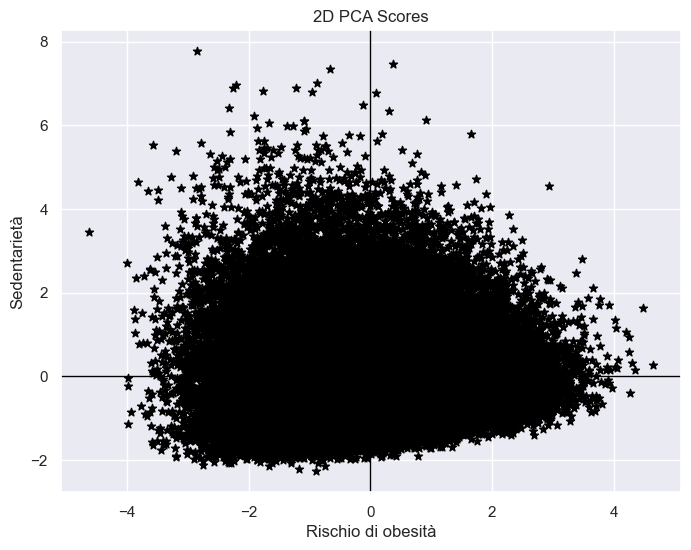

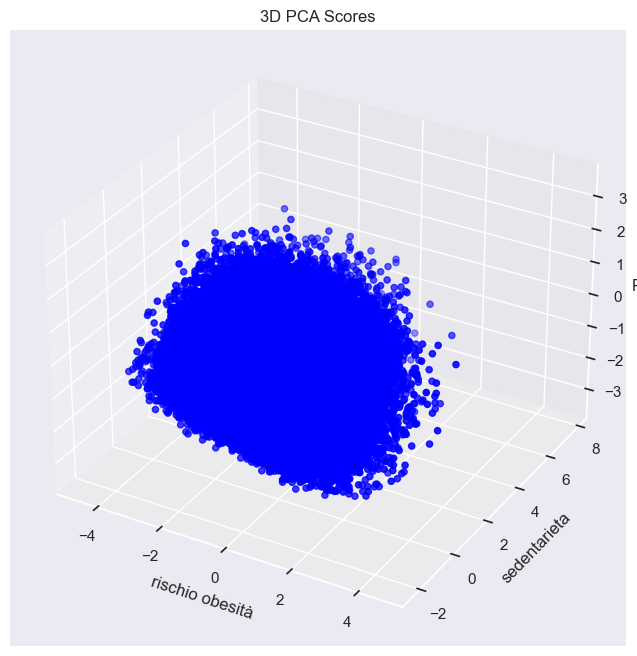

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select the relevant numeric columns
vars_to_scale = ["bmi", "Age", "physical_activity_minutes_per_week", "diet_score"]
pca_df = df[vars_to_scale]

# Summary of the variables (equivalent to summary(pca_df))
print("--- Summary of pca_df ---")
print(pca_df.describe())

# 2. Standardization (equivalent to scale())
scaler = StandardScaler()
df_scaled = scaler.fit_transform(pca_df)

# Verify means are approx 0 and standard deviations are approx 1
# axis=0 means we calculate it for each column
print("\n--- Verification of Standardization ---")
print("Means (should be ~0):", df_scaled.mean(axis=0).round(4))
print("Standard Deviations (should be ~1):", df_scaled.std(axis=0).round(4))

# 3. Perform PCA (equivalent to princomp(cor=TRUE))
pca = PCA()
pca_scores = pca.fit_transform(df_scaled) # These are the pca_result$scores

# 4. Variance explained by each component (equivalent to summary(pca_result))
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    "Proportion of Variance": explained_variance,
    "Cumulative Proportion": cumulative_variance
}, index=[f"Comp.{i+1}" for i in range(len(explained_variance))])

print("\n--- PCA Summary (Explained Variance) ---")
print(pca_summary)

# 5. PCA Loadings (equivalent to print(..., loading=TRUE))
# This shows how much each original variable contributes to each Principal Component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"Comp.{i+1}" for i in range(len(vars_to_scale))],
    index=vars_to_scale
)
print("\n--- PCA Loadings ---")
print(loadings)

# 6. 2D Scatter Plot (equivalent to matplot with abline)
plt.figure(figsize=(8, 6))
# marker='*' is the Python equivalent of pch=8 in R
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], marker='*', color='black')
plt.axhline(0, color='black', linewidth=1) # Horizontal line at 0
plt.axvline(0, color='black', linewidth=1) # Vertical line at 0
plt.xlabel("Rischio di obesità")
plt.ylabel("Sedentarietà")
plt.title("2D PCA Scores")
plt.show()

# 7. 3D Scatter Plot (equivalent to scatterplot3d)
fig = plt.figure(figsize=(10, 8))
# projection='3d' automatically creates a 3D axis
ax = fig.add_subplot(111, projection='3d')
# marker='o' is the Python equivalent of pch=19 (solid circle)
ax.scatter(pca_scores[:, 0], pca_scores[:, 1], pca_scores[:, 2], color='blue', marker='o')
ax.set_xlabel("rischio obesità")
ax.set_ylabel("sedentarieta")
ax.set_zlabel("PC3")
plt.title("3D PCA Scores")
plt.show()

## Linear Discriminant ANalysis (LDA)
Fitting the LDA model, analyzing LD1 scores, and evaluating performance.

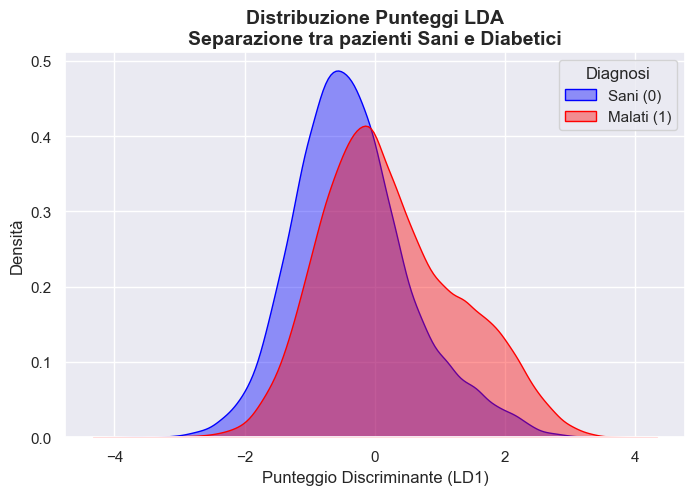

In [42]:
# %%
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Variables Definition
vars_continue = ["Age", "bmi", "physical_activity_minutes_per_week", "diet_score"]
vars_fattori = ["cardiovascular_history", "family_history_diabetes"]
features = vars_continue + vars_fattori

# Create a copy to avoid modifying the original dataframe
df_lda = df.copy()

# Standardization (Only on continuous variables, as in R)
scaler = StandardScaler()
df_lda[vars_continue] = scaler.fit_transform(df_lda[vars_continue])

# Define X (predictors) and y (target)
X_lda = df_lda[features]
y_lda = df_lda['diagnosed_diabetes']

# Fit the LDA Model
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_lda, y_lda)

# Predictions, Scores, and Probabilities
# .transform() calculates the LD1 score (equivalent to pred_lda$x)
ld1_scores = lda_model.transform(X_lda).ravel()
# .predict() automatically classifies 0 or 1 based on the algorithm's optimal threshold
pred_class = lda_model.predict(X_lda)
# .predict_proba() extracts probabilities. We take column [1] for the "Diabetic" probability
probs_lda = lda_model.predict_proba(X_lda)[:, 1]

# --- Density Plot of LDA Scores ---
# Optimized: We plot directly from the arrays without creating temporary dataframes
plt.figure(figsize=(8, 5))

# sns.kdeplot mimics ggplot's geom_density perfectly
sns.kdeplot(x=ld1_scores[y_lda == 0], fill=True, color="blue", alpha=0.4, label="Sani (0)")
sns.kdeplot(x=ld1_scores[y_lda == 1], fill=True, color="red", alpha=0.4, label="Malati (1)")

plt.title("Distribuzione Punteggi LDA\nSeparazione tra pazienti Sani e Diabetici", fontsize=14, fontweight='bold')
plt.xlabel("Punteggio Discriminante (LD1)")
plt.ylabel("Densità")
plt.legend(title="Diagnosi", loc="upper right")
plt.show()


--- Confusion Matrix (LDA) ---
               Predicted Diabetic  Predicted Healthy
Real Diabetic               47135              10021
Real Healthy                25095              13082

Accuracy:    0.6316
Sensitivity: 0.8247
Specificity: 0.3427



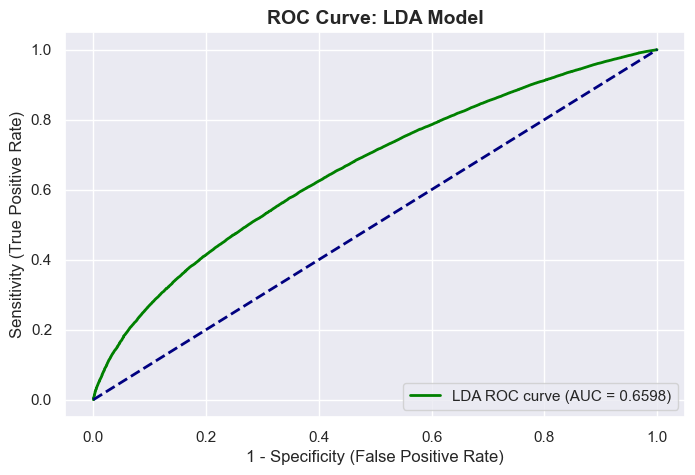

AUC (LDA Model): 0.6598


In [43]:
# --- Confusion Matrix & Metrics ---
tn, fp, fn, tp = confusion_matrix(y_lda, pred_class).ravel()

tab_lda = pd.DataFrame(
    [[tp, fn], [fp, tn]],
    columns=["Predicted Diabetic", "Predicted Healthy"],
    index=["Real Diabetic", "Real Healthy"]
)
print("\n--- Confusion Matrix (LDA) ---")
print(tab_lda)

accuracy_lda = (tn + tp) / len(y_lda)
sensitivity_lda = tp / (tp + fn)
specificity_lda = tn / (tn + fp)

print(f"\nAccuracy:    {accuracy_lda:.4f}")
print(f"Sensitivity: {sensitivity_lda:.4f}")
print(f"Specificity: {specificity_lda:.4f}\n")

# --- ROC Curve and AUC ---
fpr_lda, tpr_lda, thresholds_lda = roc_curve(y_lda, probs_lda)
roc_auc_lda = roc_auc_score(y_lda, probs_lda)

plt.figure(figsize=(8, 5))
# Plotted in green as requested
plt.plot(fpr_lda, tpr_lda, color='green', lw=2, label=f'LDA ROC curve (AUC = {roc_auc_lda:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.title('ROC Curve: LDA Model', fontsize=14, fontweight='bold')
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.legend(loc="lower right")
plt.show()

print(f"AUC (LDA Model): {roc_auc_lda:.4f}")

In [44]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Fit the QDA Model
# We reuse X_lda and y_lda from the previous LDA cell
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_lda, y_lda)

# Class Counts (Equivalent to qda_model$counts)
print("--- Counts per Group ---")
print(y_lda.value_counts().sort_index())

# Predictions and Probabilities
pred_class_qda = qda_model.predict(X_lda)
post_probs_qda = qda_model.predict_proba(X_lda)[:, 1]

# Confusion Matrix QDA
tn_q, fp_q, fn_q, tp_q = confusion_matrix(y_lda, pred_class_qda).ravel()

tab_qda = pd.DataFrame(
    [[tp_q, fn_q], [fp_q, tn_q]],
    columns=["Predicted Diabetic", "Predicted Healthy"],
    index=["Real Diabetic", "Real Healthy"]
)

print("\n--- Confusion Matrix (QDA) ---")
print(tab_qda)

# Accuracy calculation
accuracy_qda = (tn_q + tp_q) / len(y_lda)
print(f"\nAccuracy (QDA): {accuracy_qda:.4f}")

# AUC QDA
roc_auc_qda = roc_auc_score(y_lda, post_probs_qda)
print(f"AUC (QDA):      {roc_auc_qda:.4f}")

--- Counts per Group ---
diagnosed_diabetes
0    38177
1    57156
Name: count, dtype: int64

--- Confusion Matrix (QDA) ---
               Predicted Diabetic  Predicted Healthy
Real Diabetic               36877              20279
Real Healthy                16338              21839

Accuracy (QDA): 0.6159
AUC (QDA):      0.6532


## Quadratic Discriminant Analysis (QDA)
Fitting the QDA model, evaluating its performance, and comparing it with LDA.

## Model Comparison: LDA vs QDA
Comparing ROC curves and the correlation of posterior probabilities.

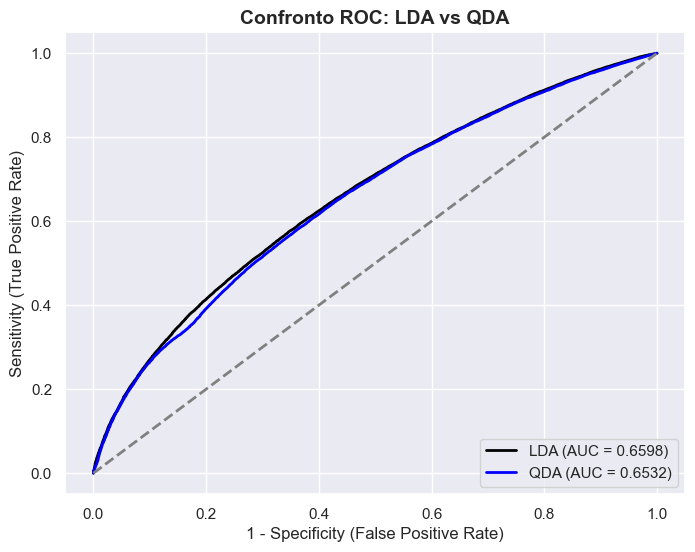

Correlazione LDA vs QDA: 0.9164


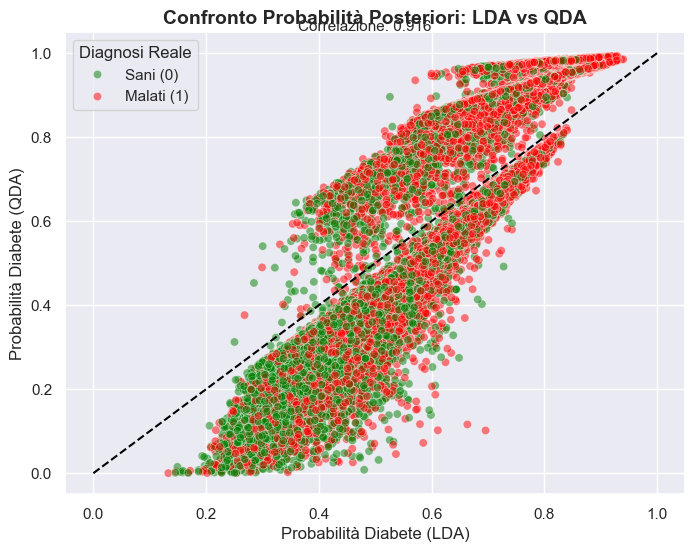

In [45]:
# Calcolo Curva ROC per QDA
fpr_qda, tpr_qda, _ = roc_curve(y_lda, post_probs_qda)

# --- Grafico 1: Confronto ROC (LDA vs QDA) ---
plt.figure(figsize=(8, 6))
# Aggiungiamo la curva LDA (nera) e QDA (blu)
plt.plot(fpr_lda, tpr_lda, color='black', lw=2, label=f'LDA (AUC = {roc_auc_lda:.4f})')
plt.plot(fpr_qda, tpr_qda, color='blue', lw=2, label=f'QDA (AUC = {roc_auc_qda:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.title('Confronto ROC: LDA vs QDA', fontsize=14, fontweight='bold')
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.legend(loc="lower right")
plt.show()

# Calcolo Correlazione tra le probabilità (Equivalent to cor())
# np.corrcoef returns a matrix, we extract the intersection [0, 1]
correlazione = np.corrcoef(probs_lda, post_probs_qda)[0, 1]
print(f"Correlazione LDA vs QDA: {correlazione:.4f}")

# --- Grafico 2: Scatterplot Probabilità (LDA vs QDA) ---
plt.figure(figsize=(8, 6))

# sns.scatterplot replaces ggplot + geom_point
sns.scatterplot(
    x=probs_lda,
    y=post_probs_qda,
    hue=y_lda, # Colora in base alla diagnosi
    palette={0: "green", 1: "red"},
    alpha=0.5
)

# Linea tratteggiata y=x (geom_abline in R)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

plt.title('Confronto Probabilità Posteriori: LDA vs QDA', fontsize=14, fontweight='bold')
# Sottotitolo in matplotlib
plt.suptitle(f"Correlazione: {correlazione:.3f}", y=0.90, fontsize=11)
plt.xlabel('Probabilità Diabete (LDA)')
plt.ylabel('Probabilità Diabete (QDA)')

# Rinomina la legenda
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Sani (0)", "Malati (1)"], title="Diagnosi Reale")

plt.show()

## Clustering: Lifestyle Segmentation
Hierarchical Clustering on a sample to determine the optimal number of clusters (k).

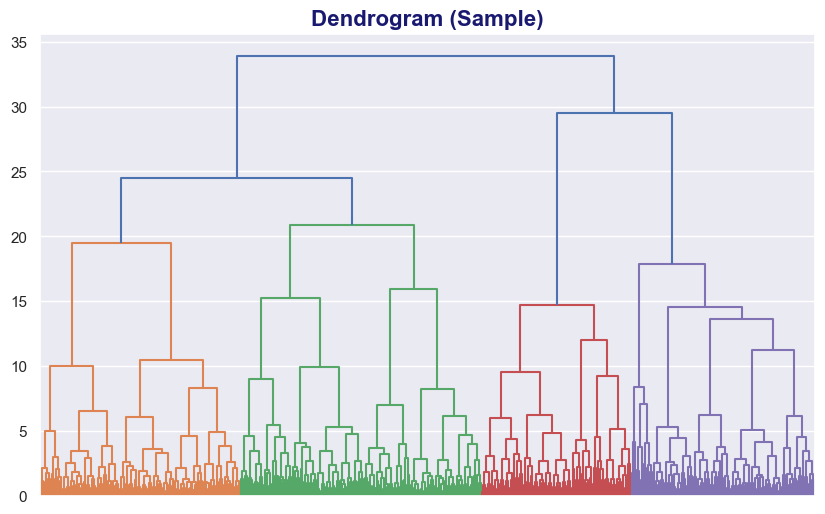

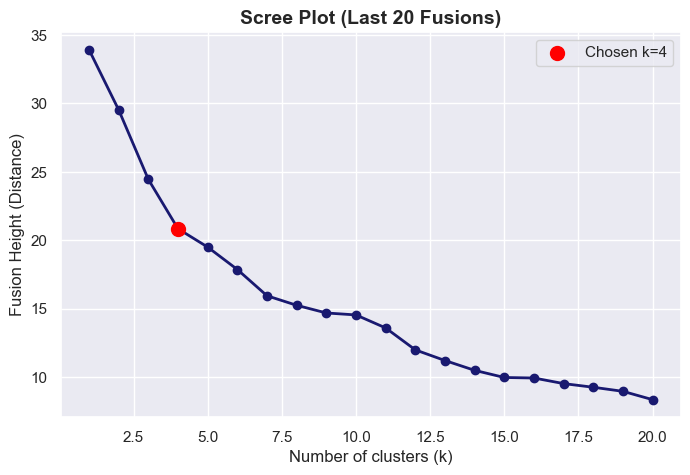

In [46]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Input Variables & Standardization
vars_lifestyle = ["Age", "bmi", "physical_activity_minutes_per_week", "diet_score"]
df_cluster_input = df[vars_lifestyle]

scaler_cluster = StandardScaler()
df_scaled_cluster = scaler_cluster.fit_transform(df_cluster_input)

# Sample 1000 rows (set.seed(123) equivalent)
np.random.seed(123)
sample_idx = np.random.choice(df_scaled_cluster.shape[0], 1000, replace=False)
df_sample = df_scaled_cluster[sample_idx]

# Compute Linkage Matrix (Ward's method with Euclidean distance)
Z = linkage(df_sample, method='ward', metric='euclidean')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
# color_threshold automatically colors the branches to show our 4 distinct clusters
dendrogram(Z, no_labels=True, color_threshold=Z[-3, 2])
plt.title("Dendrogram (Sample)", fontsize=16, color="midnightblue", fontweight='bold')
plt.show()

# Scree Plot (Last 20 fusions)
last_20_heights = Z[-20:, 2]

plt.figure(figsize=(8, 5))
# Plotting backwards from 20 to 1 just like in R
plt.plot(range(20, 0, -1), last_20_heights, marker='o', color='midnightblue', linestyle='-', lw=2)
plt.title("Scree Plot (Last 20 Fusions)", fontsize=14, fontweight='bold')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Fusion Height (Distance)")
# Highlight k=4 with a red dot
plt.scatter(4, last_20_heights[-4], color='red', s=100, zorder=5, label='Chosen k=4')
plt.legend()
plt.show()

## K-Means Clustering and Cluster Profiling
Applying K-Means to the full dataset and analyzing the medical profile of each segment.

In [47]:
from sklearn.cluster import KMeans

# Execute K-Means on ALL standardized data
# n_init=25 is the exact equivalent of nstart=25 in R
kmeans = KMeans(n_clusters=4, n_init=25, random_state=123)
km_clusters = kmeans.fit_predict(df_scaled_cluster)

# Add labels to the original dataframe (Adding +1 to match R's 1-4 numbering)
df['Cluster_Lifestyle'] = km_clusters + 1

# Convert factors to numeric temporarily to calculate percentages easily
diag_num = df['diagnosed_diabetes'].astype(float)
fam_num = df['family_history_diabetes'].astype(float)

# Cluster Profiling (Equivalent to dplyr group_by %>% summarise)
cluster_profile = df.groupby('Cluster_Lifestyle').agg(
    Group_Size=('Age', 'size'),
    Mean_Age=('Age', 'mean'),
    Mean_BMI=('bmi', 'mean'),
    Mean_Physical_Activity=('physical_activity_minutes_per_week', 'mean'),
    Mean_Diet_Score=('diet_score', 'mean')
)

# Add the external variables (Genetics and Outcome) as percentages
cluster_profile['Family_History_Pct'] = df.groupby('Cluster_Lifestyle').apply(lambda x: fam_num[x.index].mean() * 100)
cluster_profile['Diabetic_Pct'] = df.groupby('Cluster_Lifestyle').apply(lambda x: diag_num[x.index].mean() * 100)

# Round everything for a clean display
cluster_profile = cluster_profile.round(1)

print("--- CLUSTER PROFILE: LIFESTYLE & DIABETES RISK ---")
print(cluster_profile)

--- CLUSTER PROFILE: LIFESTYLE & DIABETES RISK ---
                   Group_Size  Mean_Age  Mean_BMI  Mean_Physical_Activity  \
Cluster_Lifestyle                                                           
1                       26159      40.8      27.4                    91.5   
2                       26640      66.2      27.2                    91.8   
3                       14367      50.4      24.9                   269.5   
4                       28167      43.7      22.8                    93.3   

                   Mean_Diet_Score  Family_History_Pct  Diabetic_Pct  
Cluster_Lifestyle                                                     
1                              4.5                22.1          60.7  
2                              6.0                21.7          69.7  
3                              5.9                21.5          50.6  
4                              7.3                22.2          54.8  


## Cartesian Visualization of the 4 Lifestyle Clusters
Using PCA to reduce dimensionality to 2D and drawing convex hulls around the clusters.

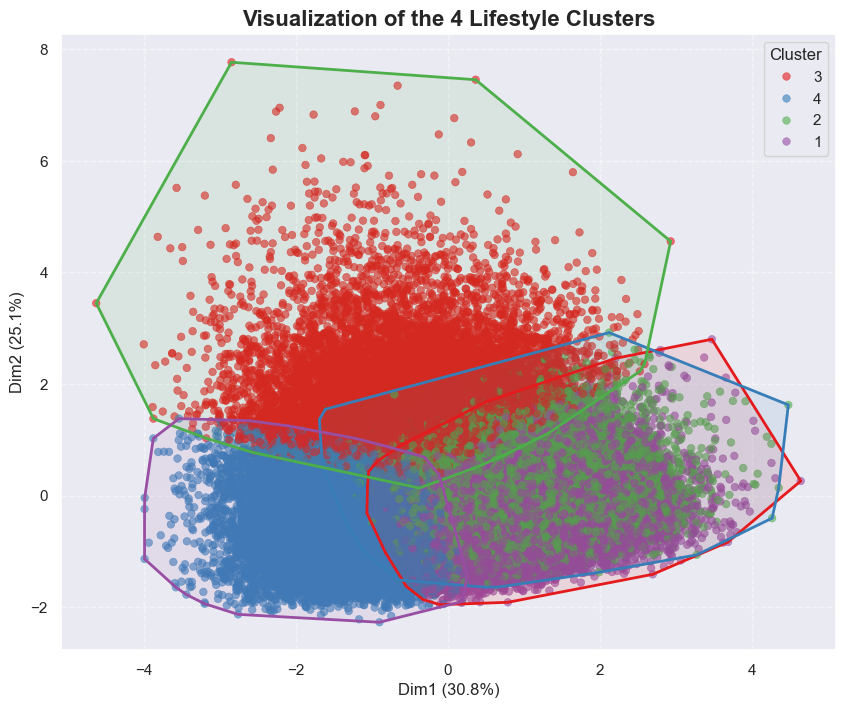

In [48]:
from scipy.spatial import ConvexHull

# Reduce the 4 lifestyle variables to 2 Dimensions using PCA
pca_clust = PCA(n_components=2)
pca_features = pca_clust.fit_transform(df_scaled_cluster)

# Create a dataframe for plotting
plot_df = pd.DataFrame({
    'Dim1': pca_features[:, 0],
    'Dim2': pca_features[:, 1],
    'Cluster': df['Cluster_Lifestyle'].astype(str) # String for categorical coloring
})

plt.figure(figsize=(10, 8))
# Set a professional palette similar to "jco" in R
palette = sns.color_palette("Set1", 4)

# Scatter plot of the points
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Cluster',
    palette=palette,
    data=plot_df,
    s=30, alpha=0.6, edgecolor=None
)

# Draw Convex Hulls (The geometric borders around the groups)
for i, cluster in enumerate(sorted(plot_df['Cluster'].unique())):
    # Get the coordinates for points in this cluster
    points = plot_df[plot_df['Cluster'] == cluster][['Dim1', 'Dim2']].values

    # Calculate and draw the hull if there are enough points
    if len(points) >= 3:
        hull = ConvexHull(points)
        # Draw the outline
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], color=palette[i], lw=2)
        # Fill the inside with a transparent color
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], color=palette[i], alpha=0.1)

# Format the axes with the explained variance percentages
var_explained = pca_clust.explained_variance_ratio_ * 100
plt.xlabel(f"Dim1 ({var_explained[0]:.1f}%)")
plt.ylabel(f"Dim2 ({var_explained[1]:.1f}%)")
plt.title("Visualization of the 4 Lifestyle Clusters", fontsize=16, fontweight='bold')
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()